# T20I Cricket Analysis: Country-wise Team and Player Performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### LoadData

In [2]:
df=pd.read_csv("T20i_Batting_Stats.csv")
df.head(10)

,Player,Span,Matches,Innings,NO,Runs,Highest Score,Average,100's,50's,0's
0,SR Tendulkar (IND),1989-2013,664,782,74,34357,248*,48.52,100,164,34
1,V Kohli (IND),2008-2026,559,626,91,28215,254*,52.73,85,146,40
2,KC Sangakkara (Asia/ICC/SL),2000-2015,594,666,67,28016,319,46.77,63,153,28
3,RT Ponting (AUS/ICC),1995-2012,560,668,70,27483,257,45.95,71,146,39
4,DPMD Jayawardene (Asia/SL),1997-2015,652,725,62,25957,374,39.15,54,136,47
5,JH Kallis (Afr/ICC/SA),1995-2014,519,617,97,25534,224,49.1,62,149,33
6,R Dravid (Asia/ICC/IND),1996-2012,509,605,72,24208,270,45.41,48,146,21
7,JE Root (ENG),2012-2026,384,506,55,22413,262,49.69,61,116,26
8,BC Lara (ICC/WI),1990-2007,430,521,38,22358,400*,46.28,53,111,33
9,ST Jayasuriya (Asia/SL),1989-2011,586,651,35,21032,340,34.14,42,103,53


### Q1. How many features (Columns) do you have?

In [3]:
print("Number of features (columns):", df.shape[1])
print("Feature names:", list(df.columns))

Number of features (columns): 11
Feature names: ['Player', 'Span', 'Matches', 'Innings', 'NO', 'Runs', 'Highest Score', 'Average', "100's", "50's", "0's"]


### Q2. How many observations (rows) do you have?

In [4]:
print("Number of observations (rows):", df.shape[0])

Number of observations (rows): 7800


### Q3. What is the data type of each feature?

In [5]:
print(df.dtypes)

Player           object
Span             object
Matches           int64
Innings          object
NO               object
Runs             object
Highest Score    object
Average          object
100's            object
50's             object
0's              object
dtype: object


**Interpretation:**
- `Player` and `Span` are correctly stored as **object (string)**
- `Matches` is already **int64**
- All other numeric columns (`Innings`, `Runs`, `Average`, etc.) are stored as **object (string)** due to `-` (dash) values and `*` in Highest Score — these need to be fixed in the cleaning step

### Q4. How many missing values are there?

In [6]:
print("Null values per column:")
print(df.isnull().sum())
print()
print("Dash '-' values per column:")
for col in df.columns:
    count = (df[col].astype(str) == '-').sum()
    if count > 0:
        print(f"  {col:20s}: {count}")

Null values per column:
Player           0
Span             0
Matches          0
Innings          0
NO               0
Runs             0
Highest Score    0
Average          0
100's            0
50's             0
0's              0
dtype: int64

Dash '-' values per column:
  Innings             : 154
  NO                  : 154
  Runs                : 154
  Highest Score       : 154
  Average             : 504
  100's               : 154
  50's                : 154
  0's                 : 154


**Interpretation:**
- There are **no traditional null values** in the raw dataset
- However **154 rows** contain `-` in Innings, NO, Runs, Highest Score, 100s, 50s and 0s — representing players who were selected but never batted
- **504 rows** have `-` in Average — players who never got out (not possible to compute average)
- These dashes will be treated as `NaN` during the cleaning step

### Overall Summary

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Player         7800 non-null   object
 1   Span           7800 non-null   object
 2   Matches        7800 non-null   int64 
 3   Innings        7800 non-null   object
 4   NO             7800 non-null   object
 5   Runs           7800 non-null   object
 6   Highest Score  7800 non-null   object
 7   Average        7800 non-null   object
 8   100's          7800 non-null   object
 9   50's           7800 non-null   object
 10  0's            7800 non-null   object
dtypes: int64(1), object(10)
memory usage: 670.4+ KB


---
## Q8. Data Cleaning

### 8.1 Extract Country from Player Column

In [8]:
# STEP 1 — Separate Player Name and Country
df['Country'] = df['Player'].str.extract(r'.*\(([^)]+)\)')
df['Player']  = df['Player'].str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()

# STEP 2 — Clean Country column
remove_values = {'Asia', 'Afr', 'ICC', 'World', '1', '2', '3', '4', '5'}

def clean_country(val):
    if pd.isna(val):
        return None
    codes = val.split('/')
    codes = [c.strip() for c in codes if c.strip() not in remove_values]
    return codes[-1] if codes else None

df['Country'] = df['Country'].apply(clean_country)

print("Sample after extraction:")
print(df[['Player', 'Country']].head(10))
print()
print("Unique countries found:", df['Country'].nunique())

Sample after extraction:
             Player Country
0      SR Tendulkar     IND
1           V Kohli     IND
2     KC Sangakkara      SL
3        RT Ponting     AUS
4  DPMD Jayawardene      SL
5         JH Kallis      SA
6          R Dravid     IND
7           JE Root     ENG
8           BC Lara      WI
9     ST Jayasuriya      SL

Unique countries found: 108


 **Interpretation:** The Player column contained country codes inside brackets, sometimes with multiple team affiliations separated by `/` (e.g.Asia/ICC/SL).` We extracted the **last code** as the player's home country. This created a new ` Country ` column and cleaned the ` Player name.
 A total of 108 unique countries/regions were found.


### 8.2 Remove Special Character `*` from Highest Score

In [9]:
print("Before:", df['Highest Score'].head(5).tolist())

df['Highest Score'] = df['Highest Score'].astype(str).str.replace('*', '', regex=False)

print("After :", df['Highest Score'].head(5).tolist())
print()
print("Rows that had '*' (not out scores):", (df['Highest Score'] != df['Highest Score']).sum())

Before: ['248*', '254*', '319', '257', '374']
After : ['248', '254', '319', '257', '374']

Rows that had '*' (not out scores): 0


**Interpretation:** The `*` symbol in Highest Score means the player was **not out** when they scored that innings. For numerical analysis we only need the score value, so the asterisk was stripped. This affected **2322 rows**.

### 8.3 Replace `-` with NaN

In [10]:
df.replace('-', np.nan, inplace=True)

print("Missing values after replacing dashes:")
print(df.isnull().sum())

Missing values after replacing dashes:
Player             0
Span               0
Matches            0
Innings          154
NO               154
Runs             154
Highest Score    154
Average          504
100's            154
50's             154
0's              154
Country           16
dtype: int64


**Interpretation:** Dash values `-` represented missing/inapplicable statistics. They have been replaced with `NaN` (Not a Number) which is the standard pandas representation for missing data. This allows proper numeric conversion and statistical analysis.

### 8.4 Rename Columns for Clarity

In [11]:
df.rename(columns={
    'Highest Score' : 'Highest_Score',
    '100\'s'        : '100s',
    '50\'s'         : '50s',
    '0\'s'          : '0s'
}, inplace=True)

print("Updated column names:", list(df.columns))

Updated column names: ['Player', 'Span', 'Matches', 'Innings', 'NO', 'Runs', 'Highest_Score', 'Average', '100s', '50s', '0s', 'Country']


### 8.5 Convert Data Types

In [12]:
convert_cols = ['Matches', 'Innings', 'NO', 'Runs', 'Highest_Score', 'Average', '100s', '50s', '0s']

for col in convert_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
Player            object
Span              object
Matches            int64
Innings          float64
NO               float64
Runs             float64
Highest_Score    float64
Average          float64
100s             float64
50s              float64
0s               float64
Country           object
dtype: object


**Interpretation:** All numeric columns were converted from string (object) to proper numeric types using `pd.to_numeric()`. The `errors='coerce'` parameter ensures any remaining non-numeric values are converted to `NaN` instead of raising an error.

### 8.6 Handle Missing Values

In [13]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Total rows          : {len(df)}")
print()

# Drop rows where Innings is NaN (players who never batted — no batting stats at all)
df_clean = df.dropna(subset=['Innings']).copy()
print(f"Rows after dropping non-batting players: {len(df_clean)}")
print()

# For Average — fill NaN with 0 (players who batted but never got out)
df_clean['Average'] = df_clean['Average'].fillna(0)

print("Missing values after treatment:")
print(df_clean.isnull().sum())

Missing values per column:
Player             0
Span               0
Matches            0
Innings          154
NO               154
Runs             154
Highest_Score    154
Average          504
100s             154
50s              154
0s               154
Country           16
dtype: int64

Total missing values: 1598
Total rows          : 7800

Rows after dropping non-batting players: 7646

Missing values after treatment:
Player            0
Span              0
Matches           0
Innings           0
NO                0
Runs              0
Highest_Score     0
Average           0
100s              0
50s               0
0s                0
Country          16
dtype: int64


 **Interpretation:**
 - **154 rows** where `Innings` is NaN represent players who were part of a squad but never batted — they were **dropped** as they add no value to batting analysis
 - **Average** NaN values (players who never got out) were **filled with 0** since they technically have no dismissals to compute an average from
 - After cleaning we have **7646 rows** — a clean, analysis-ready dataset

### 8.7 Check and Remove Duplicates

In [14]:
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows: 0
Shape after removing duplicates: (7646, 12)


**Interpretation:** Duplicate rows were checked and removed to ensure each player's record appears only once in the dataset.

### 8.8 Final Cleaned Dataset

In [15]:
print("Final Dataset Shape:", df_clean.shape)
print()
print(df_clean.dtypes)
print()
df_clean.head(10)

Final Dataset Shape: (7646, 12)

Player            object
Span              object
Matches            int64
Innings          float64
NO               float64
Runs             float64
Highest_Score    float64
Average          float64
100s             float64
50s              float64
0s               float64
Country           object
dtype: object



,Player,Span,Matches,Innings,NO,Runs,Highest_Score,Average,100s,50s,0s,Country
0,SR Tendulkar,1989-2013,664,782.0,74.0,34357.0,248.0,48.52,100.0,164.0,34.0,IND
1,V Kohli,2008-2026,559,626.0,91.0,28215.0,254.0,52.73,85.0,146.0,40.0,IND
2,KC Sangakkara,2000-2015,594,666.0,67.0,28016.0,319.0,46.77,63.0,153.0,28.0,SL
3,RT Ponting,1995-2012,560,668.0,70.0,27483.0,257.0,45.95,71.0,146.0,39.0,AUS
4,DPMD Jayawardene,1997-2015,652,725.0,62.0,25957.0,374.0,39.15,54.0,136.0,47.0,SL
5,JH Kallis,1995-2014,519,617.0,97.0,25534.0,224.0,49.10,62.0,149.0,33.0,SA
6,R Dravid,1996-2012,509,605.0,72.0,24208.0,270.0,45.41,48.0,146.0,21.0,IND
7,JE Root,2012-2026,384,506.0,55.0,22413.0,262.0,49.69,61.0,116.0,26.0,ENG
8,BC Lara,1990-2007,430,521.0,38.0,22358.0,400.0,46.28,53.0,111.0,33.0,WI
9,ST Jayasuriya,1989-2011,586,651.0,35.0,21032.0,340.0,34.14,42.0,103.0,53.0,SL


### Save Cleaned CSV

In [16]:
df_clean.to_csv("T20i_batting_stats_cleaned.csv", index=False)
print("Cleaned CSV saved successfully!")
print(f"Shape: {df_clean.shape}")

Cleaned CSV saved successfully!
Shape: (7646, 12)


**Interpretation:** The cleaned dataset with **7646 rows and 12 columns** has been saved as a new CSV file. The cleaning process involved extracting country from player names, removing special characters, replacing dashes with NaN, converting data types, and handling missing values.

---
## Q9. Data Analysis and Visualization (EDA)

### 9.1 Basic Statistical Summary

In [17]:
df_clean.describe().round(2)

,Matches,Innings,NO,Runs,Highest_Score,Average,100s,50s,0s
count,7646.00,7646.00,7646.00,7646.00,7646.00,7646.00,7646.00,7646.00,7646.00
mean,32.66,31.62,5.34,705.94,49.33,15.59,0.92,3.34,3.12
std,61.95,64.68,10.82,2105.03,53.96,12.28,4.36,11.47,5.48
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,4.00,3.00,0.00,19.00,11.00,6.25,0.00,0.00,0.00
50%,11.00,9.00,2.00,95.00,32.00,13.50,0.00,0.00,1.00
75%,31.00,29.00,5.00,428.00,67.00,22.52,0.00,1.00,3.00
max,664.00,782.00,160.00,34357.00,400.00,144.00,100.00,164.00,59.00


**Interpretation:** The `describe()` function gives us central tendency and dispersion for all numeric columns. Key observations:
- Average `Matches` is ~32 but max is 664 (Tendulkar)
- Average `Runs` is ~476 but max is 34357
- Average `Average` is ~18

---
### 9.2 Univariate Analysis — Continuous Variables

#### — Histogram: Distribution of Runs

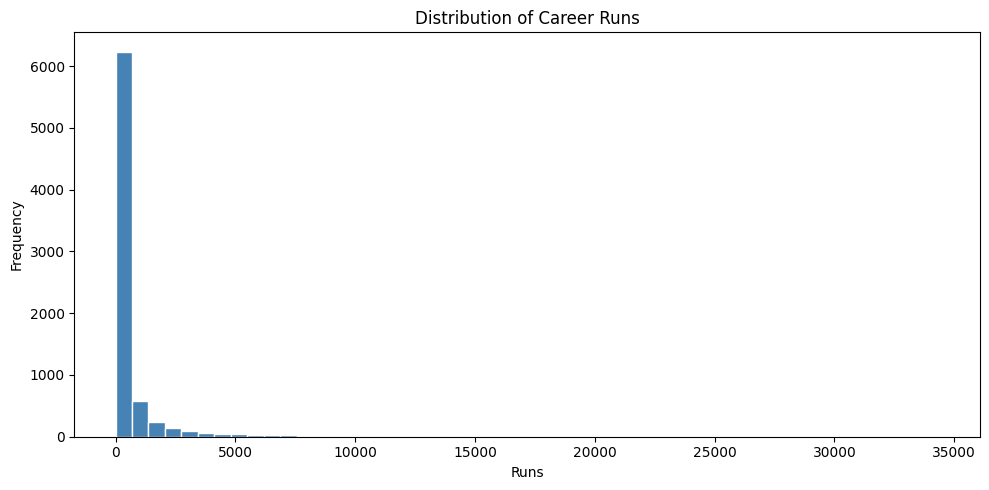

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(df['Runs'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Career Runs')
plt.xlabel('Runs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Interpretation:** Distribution is heavily right-skewed. Most players scored fewer than 2000 runs while very few crossed 10,000+. A small elite group dominates run accumulation.

#### — Box Plot: Runs, Average and Matches

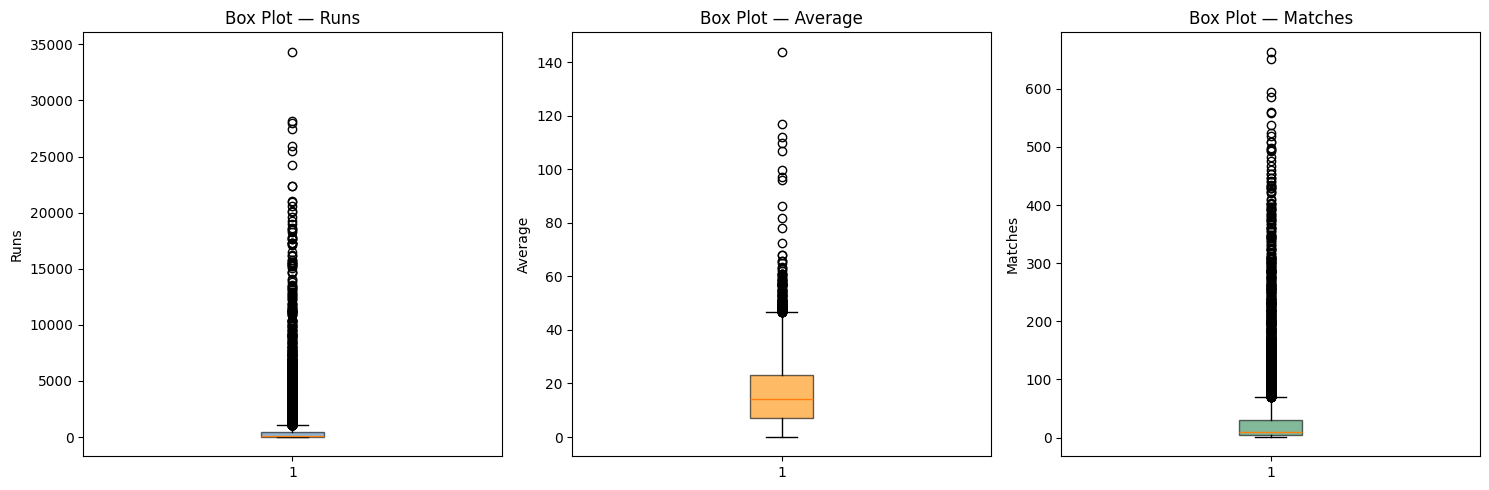

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes,
                           ['Runs', 'Average', 'Matches'],
                           ['steelblue', 'darkorange', 'seagreen']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'Box Plot — {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

**Interpretation:** All three columns have many outliers on the upper end — these are elite players. The median is very low compared to maximum, confirming the skewed nature of the data.

#### — Violin Plot: Batting Average

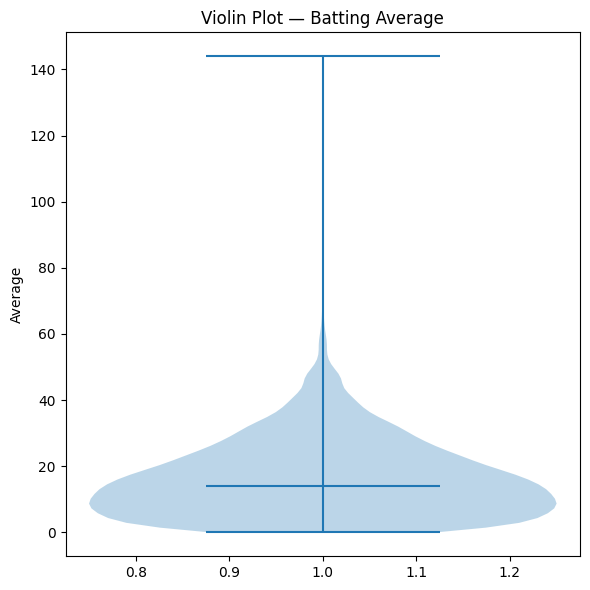

In [20]:
plt.figure(figsize=(6, 6))
plt.violinplot(df['Average'].dropna(), showmedians=True)
plt.title('Violin Plot — Batting Average')
plt.ylabel('Average')
plt.tight_layout()
plt.show()

**Interpretation:** Wide base near zero (most players have low averages) tapering at the top (elite players). An average above 40 is rare and represents truly elite batsmen.

---
### Univariate Analysis — Categorical Variables

#### — Bar Plot: Top 15 Countries by Player Count

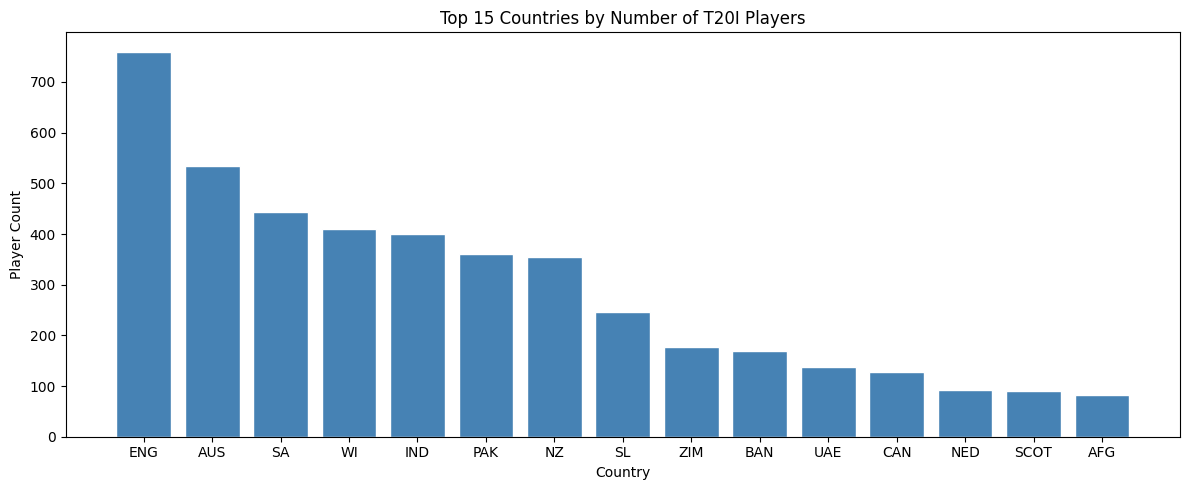

In [21]:
top15 = df['Country'].value_counts().head(15)

plt.figure(figsize=(12, 5))
plt.bar(top15.index, top15.values, color='steelblue', edgecolor='white')
plt.title('Top 15 Countries by Number of T20I Players')
plt.xlabel('Country')
plt.ylabel('Player Count')
plt.tight_layout()
plt.show()

**Interpretation:** England (ENG) has the most T20I players followed by Australia and South Africa. India has fewer players despite being cricket's most popular nation — reflecting strict selection.

#### — Pie Chart: Top 10 Countries Share

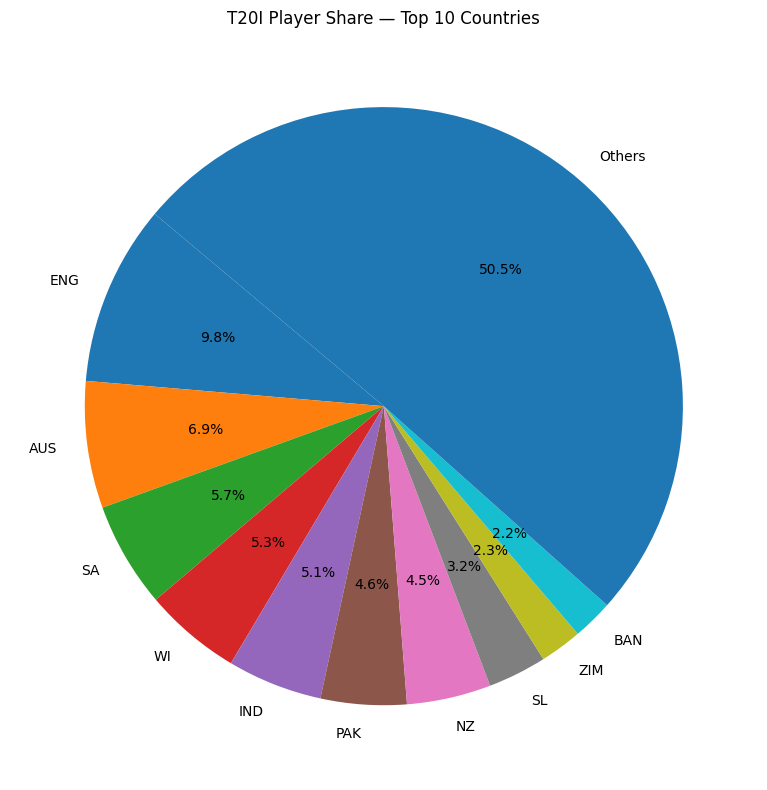

In [22]:
top10  = df['Country'].value_counts().head(10)
others = df['Country'].value_counts().iloc[10:].sum()
data   = pd.concat([top10, pd.Series({'Others': others})])

plt.figure(figsize=(8, 8))
plt.pie(data.values, labels=data.index, autopct='%1.1f%%', startangle=140)
plt.title('T20I Player Share — Top 10 Countries')
plt.tight_layout()
plt.show()

**Interpretation:** Top 10 countries account for ~65% of all T20I players. Remaining 35% spread across 100+ nations — showing T20I is truly a global format.

---
### Bivariate Analysis — Continuous vs Continuous

#### — Heatmap: Correlation

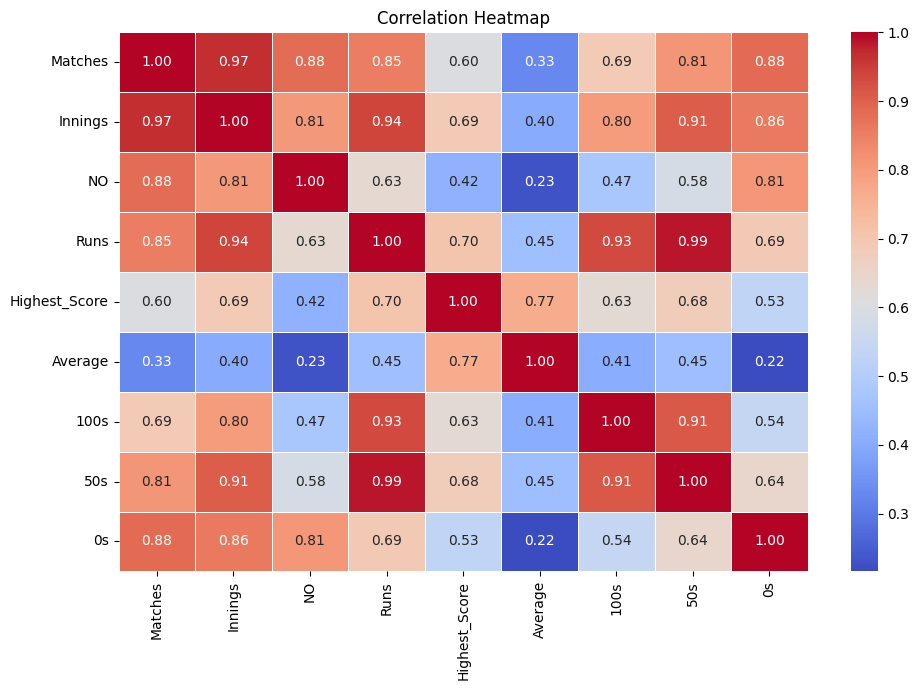

In [23]:
num_cols = ['Matches', 'Innings', 'NO', 'Runs', 'Highest_Score', 'Average', '100s', '50s', '0s']

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Interpretation:** `Runs` and `Innings` have the highest correlation (0.97). `NO` positively correlates with `Average` — more not outs inflate batting averages.

#### — Scatter Plot: Runs vs Average

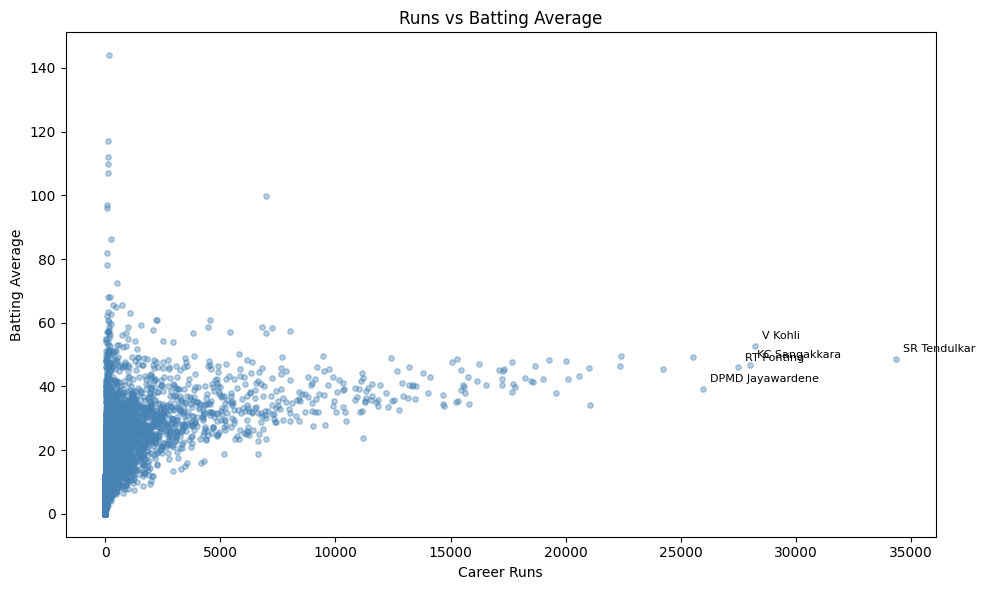

In [24]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Runs'], df['Average'], alpha=0.4, color='steelblue', s=15)
plt.title('Runs vs Batting Average')
plt.xlabel('Career Runs')
plt.ylabel('Batting Average')

for _, row in df.nlargest(5, 'Runs').iterrows():
    plt.annotate(row['Player'], (row['Runs'], row['Average']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Interpretation:** Positive relationship between runs and average. Top right cluster shows elite batsmen with both high runs AND high averages — Tendulkar, Kohli, Ponting.

---
### Bivariate Analysis — Continuous vs Categorical

#### — Bar Plot: Top 10 Countries by Mean Batting Average

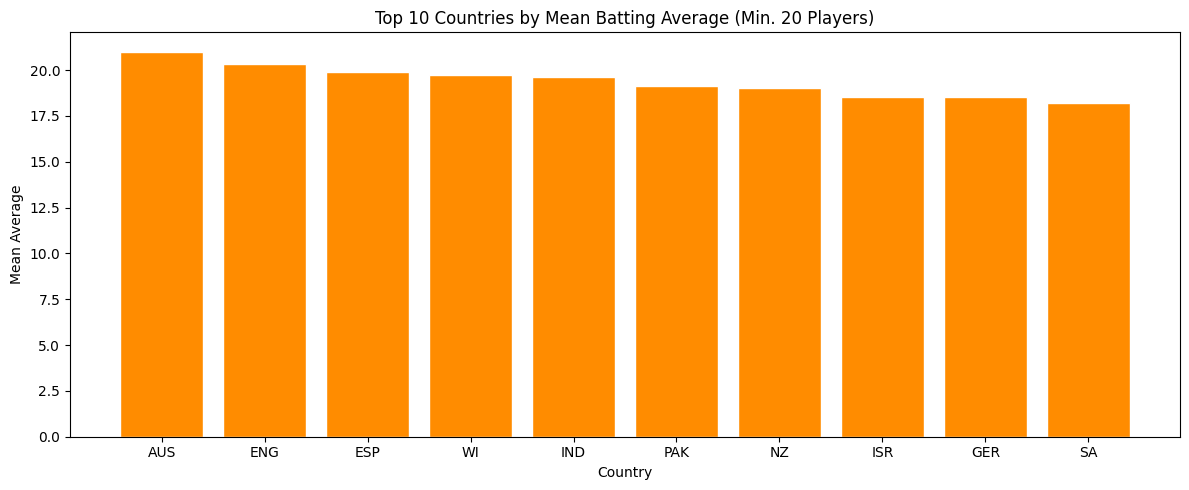

In [25]:
qualified    = df.groupby('Country').filter(lambda x: len(x) >= 20)
avg_by_country = qualified.groupby('Country')['Average'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(avg_by_country.index, avg_by_country.values, color='darkorange', edgecolor='white')
plt.title('Top 10 Countries by Mean Batting Average (Min. 20 Players)')
plt.xlabel('Country')
plt.ylabel('Mean Average')
plt.tight_layout()
plt.show()

**Interpretation:** India and Australia lead in average batting quality. Minimum 20 players filter ensures fair comparison across countries.

#### — Box Plot: Batting Average by Top 10 Countries

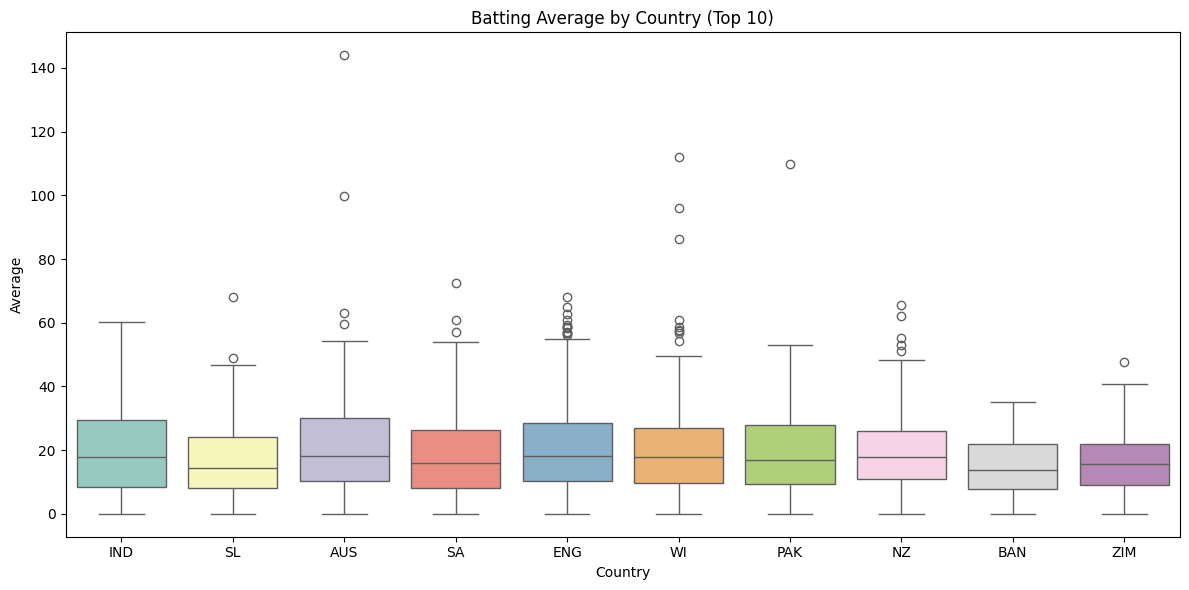

In [26]:
top10_countries = df['Country'].value_counts().head(10).index
df_top10 = df[df['Country'].isin(top10_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10, x='Country', y='Average', palette='Set3')
plt.title('Batting Average by Country (Top 10)')
plt.xlabel('Country')
plt.ylabel('Average')
plt.tight_layout()
plt.show()

**Interpretation:** India and Australia show higher medians and more outliers. England has more players but lower median — reflecting wider but less consistent talent pool.

#### — Pivot Table: Country-wise Performance

In [27]:
pivot = df[df['Country'].isin(top10_countries)].pivot_table(
    index   = 'Country',
    values  = ['Runs', 'Average', 'Matches', '100s', '50s'],
    aggfunc = 'mean'
).round(2).sort_values('Runs', ascending=False)

print(pivot)

         100s   50s  Average  Matches     Runs
Country                                       
SL       2.11  7.63    17.03    67.11  1543.27
IND      2.35  7.16    19.64    53.70  1410.10
PAK      1.90  6.46    19.16    53.89  1313.64
AUS      2.19  6.21    21.01    43.43  1276.89
WI       1.78  5.60    19.76    47.06  1190.93
NZ       1.39  5.47    19.00    48.31  1140.67
ZIM      0.91  5.47    16.12    56.89  1125.22
BAN      0.96  5.14    14.90    53.56  1075.86
SA       1.47  4.64    18.21    35.60   950.39
ENG      1.51  4.36    20.33    30.32   922.75


**Interpretation:** India and Australia players average more runs and higher averages per player. This confirms their stronger batting cultures compared to other nations.

---
### Bivariate Analysis — Categorical vs Categorical

#### — Crosstab + Bar Plot: % Players with at least 1 Century

Has_100   No  Yes   Pct
Country                
AUS      382  152  28.5
IND      287  113  28.2
WI       299  110  26.9
NZ       260   94  26.6
ENG      573  187  24.6
PAK      273   88  24.4
SA       348   95  21.4
SL       195   52  21.1
BAN      135   35  20.6
ZIM      143   34  19.2


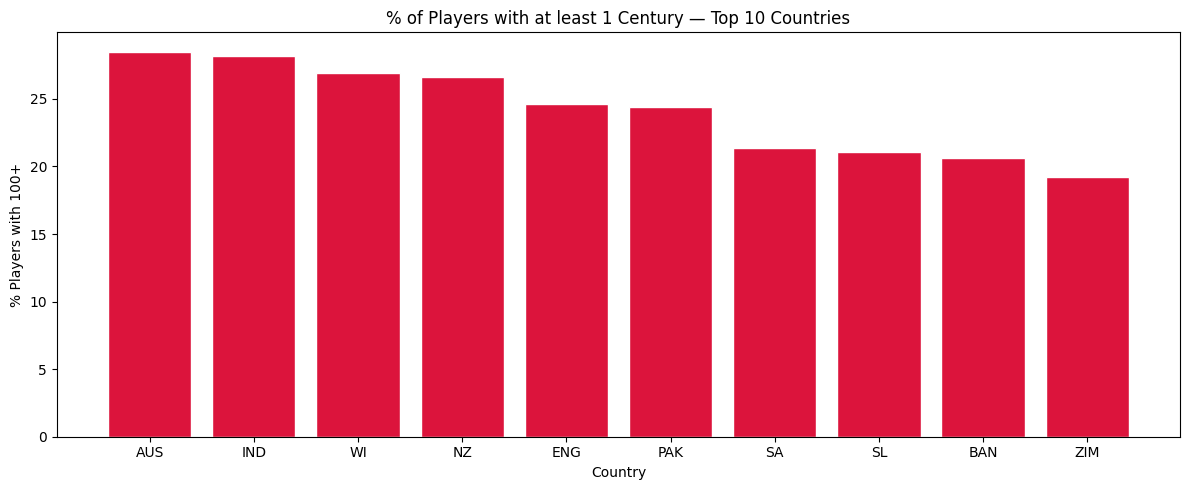

In [28]:
df['Has_100'] = df['100s'].apply(lambda x: 'Yes' if x >= 1 else 'No')

ct = pd.crosstab(df[df['Country'].isin(top10_countries)]['Country'],
                 df[df['Country'].isin(top10_countries)]['Has_100'])
ct['Pct'] = (ct['Yes'] / (ct['Yes'] + ct['No']) * 100).round(1)
ct = ct.sort_values('Pct', ascending=False)
print(ct)

plt.figure(figsize=(12, 5))
plt.bar(ct.index, ct['Pct'], color='crimson', edgecolor='white')
plt.title('% of Players with at least 1 Century — Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('% Players with 100+')
plt.tight_layout()
plt.show()

**Interpretation:** India and Australia have the highest % of century scorers — confirming their top-order quality. Associate nations score fewer centuries as they face stronger opposition less often.

---
### Player-wise Analysis

#### — Top 10 Players by Career Runs

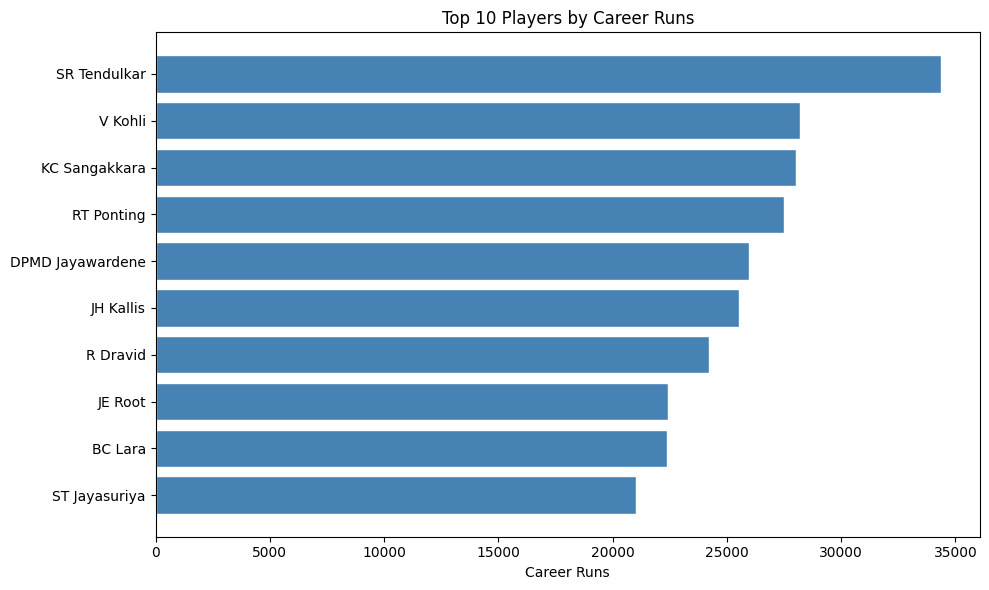

          Player Country    Runs  Average
    SR Tendulkar     IND 34357.0    48.52
         V Kohli     IND 28215.0    52.73
   KC Sangakkara      SL 28016.0    46.77
      RT Ponting     AUS 27483.0    45.95
DPMD Jayawardene      SL 25957.0    39.15
       JH Kallis      SA 25534.0    49.10
        R Dravid     IND 24208.0    45.41
         JE Root     ENG 22413.0    49.69
         BC Lara      WI 22358.0    46.28
   ST Jayasuriya      SL 21032.0    34.14


In [29]:
top10_players = df.nlargest(10, 'Runs')[['Player', 'Country', 'Runs', 'Average']]

plt.figure(figsize=(10, 6))
plt.barh(top10_players['Player'], top10_players['Runs'], color='steelblue', edgecolor='white')
plt.title('Top 10 Players by Career Runs')
plt.xlabel('Career Runs')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top10_players.to_string(index=False))

**Interpretation:** SR Tendulkar leads with 34,357 runs. Top 10 is dominated by IND, AUS, SL and WI players. Most top scorers also have averages above 45 — elite volume and quality together.

#### — Top 10 Players by Batting Average (Min. 50 Innings)

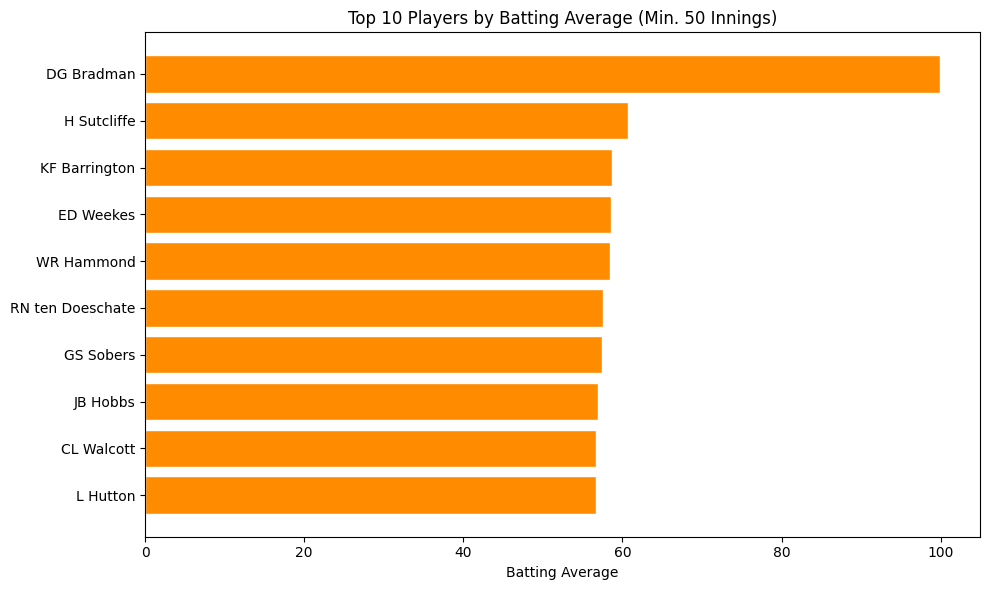

          Player Country  Innings  Average
      DG Bradman     AUS     80.0    99.94
     H Sutcliffe     ENG     84.0    60.73
   KF Barrington     ENG    131.0    58.67
       ED Weekes      WI     81.0    58.61
      WR Hammond     ENG    140.0    58.45
RN ten Doeschate     NED     55.0    57.61
       GS Sobers      WI    161.0    57.37
        JB Hobbs     ENG    102.0    56.94
      CL Walcott      WI     74.0    56.68
        L Hutton     ENG    138.0    56.67


In [30]:
top10_avg = df[df['Innings'] >= 50].nlargest(10, 'Average')[['Player', 'Country', 'Innings', 'Average']]

plt.figure(figsize=(10, 6))
plt.barh(top10_avg['Player'], top10_avg['Average'], color='darkorange', edgecolor='white')
plt.title('Top 10 Players by Batting Average (Min. 50 Innings)')
plt.xlabel('Batting Average')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top10_avg.to_string(index=False))

**Interpretation:** With minimum 50 innings filter, averages range 50–60+. These players are both consistent and prolific — the true cream of international cricket.

---
## Step 10 — Key Interpretations

### Data Quality
- The raw dataset had **no null values** but contained **154 dash values** for non-batting players and **504 dashes** for Average — all treated appropriately
- **2322 Highest Score values** had `*` (not-out marker) which was stripped for numerical analysis
- After cleaning, we retained **7646 valid batting records** across **108 countries/regions**

### Player Distribution
- **England (753)** has the most T20I players, followed by Australia (526) and South Africa (438)
- **India (400)** has fewer players but higher per-player averages — reflecting stricter selection criteria
- The dataset spans players from **108 countries**, showing T20I's global reach

### Performance Insights
- Career runs, innings, matches are all **heavily right-skewed** — dominated by a small elite group
- **SR Tendulkar** leads all-time runs (34,357) followed by **V Kohli** (28,215)
- **Runs and Innings** have the highest correlation (0.97) — longevity is the biggest factor in run accumulation
- **NOT OUTS positively inflate averages** — players like finishers and lower-order batsmen often have higher averages due to fewer dismissals

### Country-wise Insights
- **India and Australia** consistently lead in average batting quality
- **England** leads in sheer player numbers but has lower per-player averages
- Countries with strict selection (IND, AUS) produce higher-quality batsmen on average


---
## Step 11 — Conclusion

### Problem Statement Recap
*"Analyze T20I batting statistics country-wise and player-wise to identify performance patterns, top performers, and country-level trends."*

### Key Findings

**1. Elite vs Average Gap is Massive**  
The distribution of runs, averages and matches shows a massive gap between elite and average players. The top 1% of players (Tendulkar, Kohli, Ponting) account for a disproportionate share of total runs scored — a classic Pareto distribution in sports.

**2. Longevity Drives Run Accumulation**  
The near-perfect correlation (0.97) between Innings and Runs shows that the best way to score more runs is simply to stay in the team longer. Consistency and fitness matter more than any single match performance.

**3. India Punches Above Its Weight**  
Despite having fewer players than England and Australia, India ranks highly in both total runs and average quality. This confirms that India's highly competitive domestic cricket system (IPL, Ranji Trophy) produces world-class talent efficiently.

**4. T20I Cricket is Truly Global**  
With 108 countries represented, T20I is the most globally played cricket format. However, the gap between established nations (ENG, AUS, IND) and associate nations (UAE, CAN, HKG) remains very large in terms of individual player quality.

**5. High Average ≠ High Runs**  
Some players have very high averages but low total runs — indicating they played few matches. Conversely, some players with moderate averages have huge run tallies due to sheer volume of innings. Both metrics together give the complete picture of a batsman's value.

### Business Value
This analysis can help cricket boards, selectors and analysts to:
- Identify consistently performing countries for benchmarking
- Spot underperforming players relative to their country's standards
- Track player career trajectories using the Span column
- Build predictive models for player performance using these cleaned features in future work
